<a href="https://colab.research.google.com/github/cpython-projects/python_da_17_03_26/blob/main/lesson_19_hw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Датасет:** [House Sales in King County, USA (Kaggle)](https://www.kaggle.com/datasets/harlfoxem/housesalesprediction)
Файл: `kc_house_data.csv`

**!** Не рахуйте середнє одразу. Розподіл цін у нашому датасеті має сильний правий перекіс (high skewness) — довгий хвіст із наддорогих об'єктів. Якщо рахувати середнє «в лоб», ви отримаєте цифри, які не існують у реальності для 90% населення.

In [1]:
import pandas as pd

In [6]:
df = pd.read_csv('https://raw.githubusercontent.com/cpython-projects/python_da_17_03_26/refs/heads/main/kc_house_data.csv')

## Task 1
Потрібно зрозуміти, чи дійсно кількість спалень прямо пропорційна вартості житла.
Порахуй, будь ласка, середню ціну будинків залежно від кількості спалень. Нам треба виділити ті категорії, де нерухомість коштує аномально дорого або дешево для свого розміру».

<Axes: >

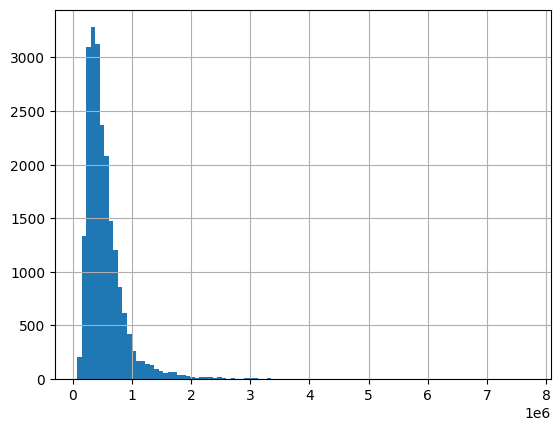

In [3]:
df.price.hist(bins=100)

<Axes: >

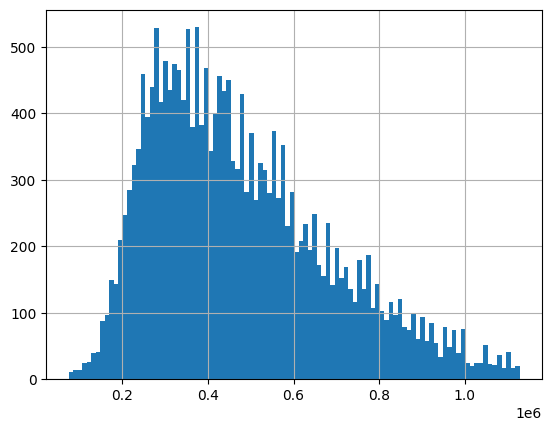

In [4]:
# Q1 = df.price.quantile(0.25)
# Q3 = df.price.quantile(0.75)
# IQR = Q3 - Q1
# upper = Q3 + 1.5 * IQR

# df = df[df.price <= upper]
# df.price.hist(bins=100)

<Axes: >

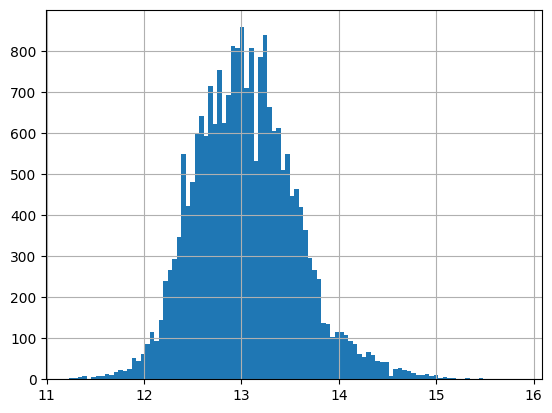

In [7]:
import numpy as np


df['log_price'] = np.log1p(df.price)

df.log_price.hist(bins=100)

In [12]:
df_task_1 = df.groupby('bedrooms').agg(
    median_price=('price', 'median'),
    mean_log_price=('log_price', 'mean'),
    count_items=('id', 'count')
).reset_index()

df_task_1['mean_price'] = np.exp(df_task_1.mean_log_price)
df_task_1 = df_task_1.drop(columns='mean_log_price')
df_task_1

,bedrooms,median_price,count_items,mean_price
0,0,288000.0,13,322370.165896
1,1,299000.0,199,285931.432101
2,2,374000.0,2760,361978.886136
3,3,413000.0,9824,415283.239887
4,4,549997.5,6882,552682.865830
5,5,620000.0,1601,652970.491597
6,6,650000.0,272,662768.625455
7,7,728580.0,38,764769.447826
8,8,700000.0,13,850940.829803
9,9,817000.0,6,825451.506133


In [13]:
import plotly.express as px

px.line(
    df_task_1,
    x='bedrooms',
    y='mean_price'
)

## Task 2
Ми готуємо звіт по якості забудови (grade). Для кожного рівня якості мені потрібна повна картина: скільки всього таких об'єктів у базі, яка мінімальна та максимальна ціна в кожній групі».

In [14]:
df_task_2 = df.groupby('grade').agg(
    median_price=('price', 'median'),
    min_price=('price', 'min'),
    max_price=('price', 'max'),
    count_items=('id', 'count')
).reset_index()

df_task_2

,grade,median_price,min_price,max_price,count_items
0,1,142000.0,142000.0,142000.0,1
1,3,262000.0,75000.0,280000.0,3
2,4,205000.0,80000.0,435000.0,29
3,5,228700.0,78000.0,795000.0,242
4,6,275276.5,82000.0,1200000.0,2038
5,7,375000.0,90000.0,2050000.0,8981
6,8,510000.0,140000.0,3070000.0,6068
7,9,720000.0,230000.0,2700000.0,2615
8,10,914327.0,316000.0,3600000.0,1134
9,11,1284000.0,420000.0,7062500.0,399


## Task 3
Інвестори питають, як змінювався ринок протягом року.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21611 non-null  float64
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [16]:
df.head(1)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,log_price
0,7129300520,20141013T000000,221900.0,3,1.0,1180,5650,1.0,0,0,...,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650,12.309987


In [17]:
df['date'] = pd.to_datetime(df.date, format='%Y%m%dT%H%M%S')
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,log_price
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,1180.0,0,1955,0,98178,47.5112,-122.257,1340,5650,12.309987
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,2170.0,400,1951,1991,98125,47.7210,-122.319,1690,7639,13.195616
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,770.0,0,1933,0,98028,47.7379,-122.233,2720,8062,12.100718
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,1050.0,910,1965,0,98136,47.5208,-122.393,1360,5000,13.311331
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,1680.0,0,1987,0,98074,47.6168,-122.045,1800,7503,13.142168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,2014-05-21,360000.0,3,2.50,1530,1131,3.0,0,0,...,1530.0,0,2009,0,98103,47.6993,-122.346,1530,1509,12.793862
21609,6600060120,2015-02-23,400000.0,4,2.50,2310,5813,2.0,0,0,...,2310.0,0,2014,0,98146,47.5107,-122.362,1830,7200,12.899222
21610,1523300141,2014-06-23,402101.0,2,0.75,1020,1350,2.0,0,0,...,1020.0,0,2009,0,98144,47.5944,-122.299,1020,2007,12.904461
21611,291310100,2015-01-16,400000.0,3,2.50,1600,2388,2.0,0,0,...,1600.0,0,2004,0,98027,47.5345,-122.069,1410,1287,12.899222


In [18]:
df['month'] = df.date.dt.to_period('M')
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,log_price,month
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,0,1955,0,98178,47.5112,-122.257,1340,5650,12.309987,2014-10
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,13.195616,2014-12
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,0,1933,0,98028,47.7379,-122.233,2720,8062,12.100718,2015-02
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,910,1965,0,98136,47.5208,-122.393,1360,5000,13.311331,2014-12
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,0,1987,0,98074,47.6168,-122.045,1800,7503,13.142168,2015-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,2014-05-21,360000.0,3,2.50,1530,1131,3.0,0,0,...,0,2009,0,98103,47.6993,-122.346,1530,1509,12.793862,2014-05
21609,6600060120,2015-02-23,400000.0,4,2.50,2310,5813,2.0,0,0,...,0,2014,0,98146,47.5107,-122.362,1830,7200,12.899222,2015-02
21610,1523300141,2014-06-23,402101.0,2,0.75,1020,1350,2.0,0,0,...,0,2009,0,98144,47.5944,-122.299,1020,2007,12.904461,2014-06
21611,291310100,2015-01-16,400000.0,3,2.50,1600,2388,2.0,0,0,...,0,2004,0,98027,47.5345,-122.069,1410,1287,12.899222,2015-01


In [20]:
task_3 = df.groupby('month').agg(
    median_price=('price', 'median'),
    count=('id', 'count')
).reset_index()
task_3

,month,median_price,count
0,2014-05,465000.0,1768
1,2014-06,465000.0,2180
2,2014-07,465000.0,2211
3,2014-08,442100.0,1940
4,2014-09,450000.0,1774
5,2014-10,446900.0,1878
6,2014-11,435000.0,1411
7,2014-12,432500.0,1471
8,2015-01,438500.0,978
9,2015-02,425545.0,1250


In [26]:
task_3['month'] = df['month'].dt.to_timestamp()
task_3 = task_3.sort_values(by='month')

px.line(
    task_3,
    x='month',
    y='median_price'
    )

## Task 4
Ми хочемо розробити маркетингову стратегію для трьох типів клієнтів: тих, хто шукає "історичні" будинки (до 1950 року), "класику" (1950–2000) та "новобудови" (після 2000-го).
Розбий всі будинки на ці три групи за роком будівництва та скажи, у якій групі зараз найвищий середній показник стану».


In [27]:
df.columns.to_list()

['id',
 'date',
 'price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15',
 'log_price',
 'month']

In [28]:
df['building_type'] = pd.cut(
    df.yr_built,
    bins=[0, 1949, 2000, np.inf],
    labels=['Historacal', 'Classic', 'New']
)
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,log_price,month,building_type
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,1955,0,98178,47.5112,-122.257,1340,5650,12.309987,2014-10,Classic
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,1951,1991,98125,47.7210,-122.319,1690,7639,13.195616,2014-12,Classic
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,1933,0,98028,47.7379,-122.233,2720,8062,12.100718,2015-02,Historacal
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,1965,0,98136,47.5208,-122.393,1360,5000,13.311331,2014-12,Classic
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,1987,0,98074,47.6168,-122.045,1800,7503,13.142168,2015-02,Classic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,2014-05-21,360000.0,3,2.50,1530,1131,3.0,0,0,...,2009,0,98103,47.6993,-122.346,1530,1509,12.793862,2014-05,New
21609,6600060120,2015-02-23,400000.0,4,2.50,2310,5813,2.0,0,0,...,2014,0,98146,47.5107,-122.362,1830,7200,12.899222,2015-02,New
21610,1523300141,2014-06-23,402101.0,2,0.75,1020,1350,2.0,0,0,...,2009,0,98144,47.5944,-122.299,1020,2007,12.904461,2014-06,New
21611,291310100,2015-01-16,400000.0,3,2.50,1600,2388,2.0,0,0,...,2004,0,98027,47.5345,-122.069,1410,1287,12.899222,2015-01,New


## Task 5
Відділ продажів хоче розділити всі об'єкти на 5 рівних за кількістю груп — від "бюджетних" до "люкс-сегменту" (по 20% будинків у кожній).
Нам потрібно порівняти ці групи: яка середня площа житла (sqft_living) у найдешевшому сегменті порівняно з найдорожчим?»

In [29]:
df['price_group'] = pd.qcut(
    df.price,
    q=5,
    labels=['L1', 'L2', 'L3', 'L4', 'L5']
)
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,log_price,month,building_type,price_group
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,0,98178,47.5112,-122.257,1340,5650,12.309987,2014-10,Classic,L1
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,1991,98125,47.7210,-122.319,1690,7639,13.195616,2014-12,Classic,L4
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,0,98028,47.7379,-122.233,2720,8062,12.100718,2015-02,Historacal,L1
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,0,98136,47.5208,-122.393,1360,5000,13.311331,2014-12,Classic,L4
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,0,98074,47.6168,-122.045,1800,7503,13.142168,2015-02,Classic,L3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,2014-05-21,360000.0,3,2.50,1530,1131,3.0,0,0,...,0,98103,47.6993,-122.346,1530,1509,12.793862,2014-05,New,L2
21609,6600060120,2015-02-23,400000.0,4,2.50,2310,5813,2.0,0,0,...,0,98146,47.5107,-122.362,1830,7200,12.899222,2015-02,New,L3
21610,1523300141,2014-06-23,402101.0,2,0.75,1020,1350,2.0,0,0,...,0,98144,47.5944,-122.299,1020,2007,12.904461,2014-06,New,L3
21611,291310100,2015-01-16,400000.0,3,2.50,1600,2388,2.0,0,0,...,0,98027,47.5345,-122.069,1410,1287,12.899222,2015-01,New,L3


## Task 6
Я хочу побачити зведену таблицю, де в рядках буде оцінка виду (view), а в стовпцях — наявність виходу до води (waterfront).
У комірках має бути середня ціна за квадратний метр. Це допоможе нам зрозуміти, за що саме переплачують клієнти: за краєвид чи за безпосередній доступ до водойми».

In [30]:
df['price_per_m2'] = df.price / df.sqft_living

In [32]:
pd.pivot_table(
    df,
    values='price_per_m2',
    index='view',
    columns='waterfront',
    aggfunc='median'
).round(1)

waterfront,0,1
view,,
0,239.3,NaN
1,297.3,327.3
2,283.4,486.2
3,295.8,505.6
4,356.6,532.3
